<a href="https://colab.research.google.com/github/Gopi-2808/PREDICTIVE-PARADOX/blob/main/IITG.Ai_Solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [166]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from pyod.models.iforest import IForest
from sklearn.metrics import mean_absolute_percentage_error

weather_df = pd.read_excel('weather_data.xlsx', skiprows=3, names=['datetime', 'temp', 'humidity', 'apparent_temp', 'precip', 'dew_point', 'soil_temp', 'wind_dir', 'cloud_cover', 'sunshine'])
power_df = pd.read_excel('PGCB_date_power_demand.xlsx')
economy_df = pd.read_csv('economic_full_1.csv')

weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
power_df['datetime'] = pd.to_datetime(power_df['datetime'])
power_df = power_df.sort_values('datetime')

First, let's get the data loaded and tidy up the timing.

In [167]:
power_hourly = power_df.groupby(power_df['datetime'].dt.floor('h'))[['demand_mw', 'generation_mw']].max().reset_index()

full_range = pd.date_range(start=power_hourly['datetime'].min(), end=power_hourly['datetime'].max(), freq='h')
power_hourly = power_hourly.set_index('datetime').reindex(full_range).rename_axis('datetime').reset_index()

data_to_check = power_hourly[['demand_mw']].fillna(power_hourly['demand_mw'].median()).values
clf = IForest(contamination=0.01, random_state=42)
clf.fit(data_to_check)
outliers = clf.labels_

power_hourly.loc[outliers == 1, 'demand_mw'] = np.nan

power_hourly['demand_mw'] = power_hourly['demand_mw'].interpolate(method='linear').ffill().bfill()
power_hourly['generation_mw'] = power_hourly['generation_mw'].interpolate(method='linear').ffill().bfill()

Now for the economic stats. I'll spread them out to match our timeline.

In [168]:
selected_names = ['GDP (current US$)', 'Population, total', 'Urban population (% of total population)', 'Industry (including construction), value added (% of GDP)','Access to electricity (% of population)']
economic_features = economy_df[economy_df['Indicator Name'].isin(selected_names)]
econ_df = economic_features.melt(id_vars='Indicator Name', value_vars=[str(y) for y in range(2014, 2025)])
econ_df = econ_df.pivot(index='variable', columns='Indicator Name', values='value')
econ_df.index = pd.to_datetime(econ_df.index + '-01-01')
econ_daily = econ_df.reindex(pd.date_range('2014-01-01', '2024-12-31', freq='D')).interpolate().ffill().bfill()


final_df = power_hourly.merge(weather_df, on='datetime', how='left')
final_df['date'] = final_df['datetime'].dt.normalize()
final_df = final_df.merge(econ_daily, left_on='date', right_index=True, how='left').drop(columns='date')
final_df = final_df.interpolate(method='linear').ffill().bfill()

final_df = final_df.rename(columns={'GDP (current US$)': 'GDP_current_US', 'Population, total': 'Population_total', 'Urban population (% of total population)':'Urban_pop', 'Industry (including construction), value added (% of GDP)':'Industry_rise'})



Time to merge everything and add a few helpful time features.

In [169]:
#  Feature engineering
final_df['day_of_year'] = final_df['datetime'].dt.dayofyear
final_df['week_of_year'] = final_df['datetime'].dt.isocalendar().week.astype(int)
final_df['hour'] = final_df['datetime'].dt.hour
final_df['day_of_week'] = final_df['datetime'].dt.dayofweek
final_df['is_weekend'] = final_df['day_of_week'].isin([4, 5]).astype(int)
final_df['hour_sin'] = np.sin(2 * np.pi * final_df['hour'] / 24)
final_df['hour_cos'] = np.cos(2 * np.pi * final_df['hour'] / 24)
final_df['month_sin'] = np.sin(2 * np.pi * final_df['datetime'].dt.month / 12)
final_df['month_cos'] = np.cos(2 * np.pi * final_df['datetime'].dt.month / 12)
final_df['rolling_mean_6'] = final_df['demand_mw'].rolling(window=6).mean().ffill().bfill()
final_df['rolling_std_6'] = final_df['demand_mw'].rolling(window=6).std().ffill().bfill()
final_df['day_sin'] = np.sin(2 * np.pi * final_df["day_of_week"] / 7)
final_df['day_cos'] = np.cos(2 * np.pi * final_df["day_of_week"] / 7)

#  lets Create Lags
final_df['demand_lag_1'] = final_df['demand_mw'].shift(1)
final_df['demand_lag_24'] = final_df['demand_mw'].shift(24)
final_df['target_demand'] = final_df['demand_mw'].shift(-1)
final_df['demand_lag_48'] = final_df['demand_mw'].shift(48)
final_df['demand_lag_168'] = final_df['demand_mw'].shift(168)
final_df = final_df.ffill().bfill()


In [170]:
!pip install pyod

In [173]:


features = [
    'demand_mw', 'demand_lag_1', 'hour_sin', 'hour_cos', 'day_sin',
    'demand_lag_24', 'demand_lag_48', 'demand_lag_168', 'temp', 'is_weekend',
    'apparent_temp', 'month_cos', 'GDP_current_US', 'Population_total',
    'day_of_year', 'week_of_year', 'rolling_std_6'
]
target = 'target_demand'

train_mask = final_df['datetime'].dt.year < 2024
test_mask = (final_df['datetime'].dt.year >= 2024)

X_train, y_train = final_df.loc[train_mask, features], final_df.loc[train_mask, target]
X_test, y_test = final_df.loc[test_mask, features], final_df.loc[test_mask, target]

# Ensuring no information from future timestamps leaks into the past
X_train, y_train = X_train.iloc[:-1], y_train.iloc[:-1]


import lightgbm as lgb
from sklearn.metrics import mean_absolute_percentage_error

print("Training LightGBM model")
model_optimized = lgb.LGBMRegressor(
    learning_rate=0.005,
    n_estimators=2000,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model_optimized.fit(X_train, y_train)

y_pred_opt = model_optimized.predict(X_test)
mape_opt = mean_absolute_percentage_error(y_test, y_pred_opt)
print(f'LightGBM Model MAPE: {mape_opt * 100:.4f}%')
print(f'Training samples: {len(X_train)}, Testing samples: {len(X_test)}')

Training LightGBM model
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2912
[LightGBM] [Info] Number of data points in the train set: 76295, number of used features: 17
[LightGBM] [Info] Start training from score 8310.907687
LightGBM Model MAPE: 1.7574%
Training samples: 76295, Testing samples: 12805


Training untill the end of 2023 and test for after start of 2024

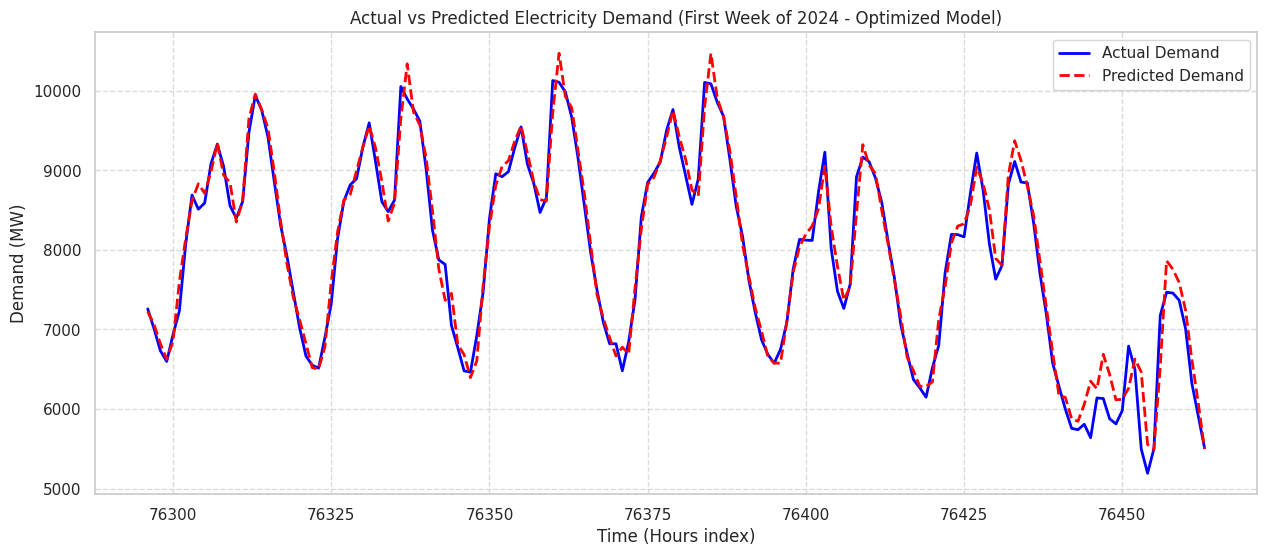

LightGBM Model MAPE: 1.7574%


In [174]:
import matplotlib.pyplot as plt

comparison_opt = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_opt}, index=X_test.index)

comparison_week = comparison_opt.iloc[:168]

# Plot actual vs predicted demand
plt.figure(figsize=(15, 6))
plt.plot(comparison_week['Actual'], label='Actual Demand', color='blue', linewidth=2)
plt.plot(comparison_week['Predicted'], label='Predicted Demand', color='red', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted Electricity Demand (First Week of 2024 - Optimized Model)')
plt.xlabel('Time (Hours index)')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Print the final MAPE score
print(f'LightGBM Model MAPE: {mape_opt * 100:.4f}%')

In [175]:
import pandas as pd


importances = model_optimized.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(f"Number of features: {len(features)}")
print(f"Number of importance scores: {len(importances)}")
print("\nTop 10 Features by Importance:")
print(feature_importance_df.head(10))

feature_importance_df

Number of features: 17
Number of importance scores: 17

Top 10 Features by Importance:
          Feature  Importance
0        hour_sin       25677
1        hour_cos       18429
2       demand_mw       15790
3     day_of_year        9689
4   rolling_std_6        9610
5  GDP_current_US        8754
6    demand_lag_1        6050
7            temp        5944
8       month_cos        5140
9   apparent_temp        3996


,Feature,Importance
0,hour_sin,25677
1,hour_cos,18429
2,demand_mw,15790
3,day_of_year,9689
4,rolling_std_6,9610
5,GDP_current_US,8754
6,demand_lag_1,6050
7,temp,5944
8,month_cos,5140
9,apparent_temp,3996


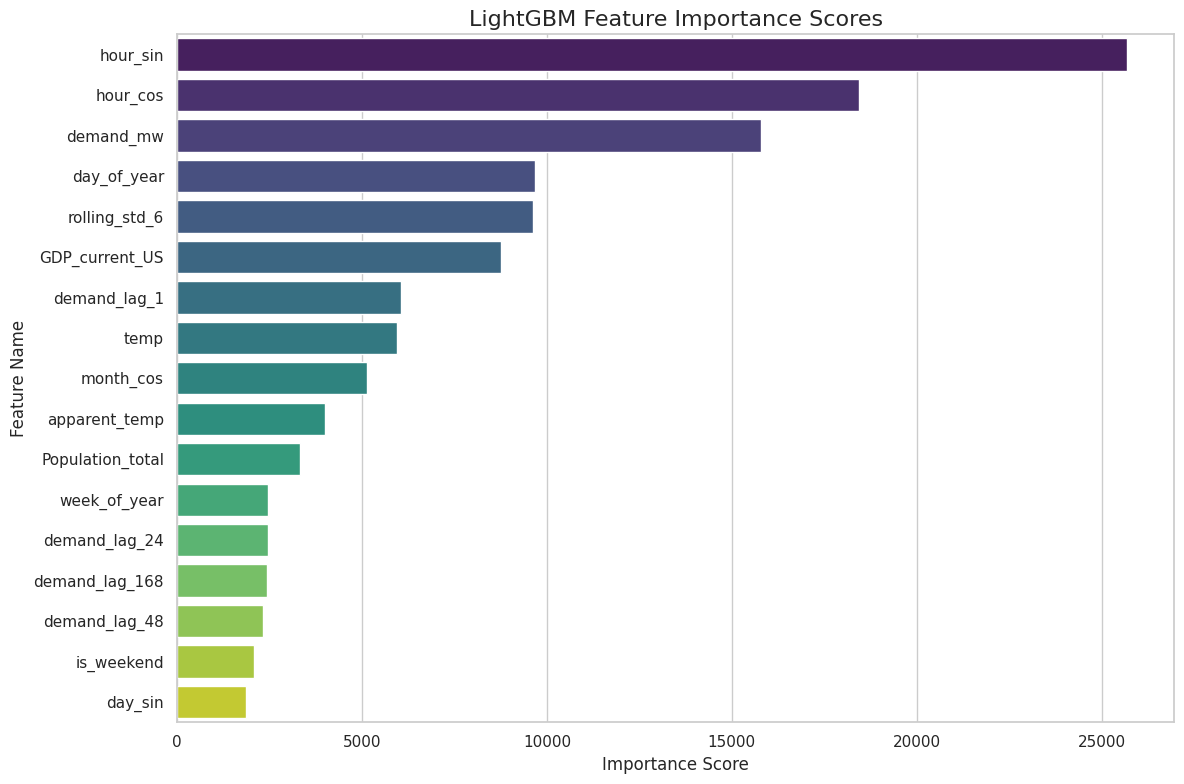

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)

plt.title('LightGBM Feature Importance Scores', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

plt.tight_layout()
plt.show()